In [1]:
# Jika belum ada
!pip install Sastrawi

import pandas as pd
import numpy as np
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data_bpjs.csv")

df.head()

,Date,Username,Comment
0,12/1/2025,worksfess,work! sender gak nyaman sama lingkungan kerja ...
1,12/2/2025,mollypinki,@undipmfs2 waktu itu aku case-nya juga sama ka...
2,12/2/2025,grok,@AntonSubagia @Bank_Joee_ @susno2g @Jediimar @...
3,12/3/2025,yourrsse,@BPJSKesehatanRI min kalo mau pindah dari bpjs...
4,12/3/2025,hamiyaaaa,Bpjs pbi akhir bln kemarin serentak pada nonak...


In [3]:
def clean_text(text):

    text = str(text).lower()

    # hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus tanda baca
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [4]:
df['clean_text'] = df['Comment'].apply(clean_text)

In [5]:
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

df['clean_text'] = df['clean_text'].apply(
    lambda x: stopword.remove(x)
)

In [6]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['clean_text'] = df['clean_text'].apply(
    lambda x: stemmer.stem(x)
)

In [7]:
positive_words = {

    'aktif',
    'mudah',
    'baik',
    'gratis',
    'bantu',
    'sehat',
    'setuju',
    'aman',
    'lancar',
    'cepat',
    'terima',
    'reaktivasi',
    'berhasil'
}

negative_words = {

    'nonaktif',
    'susah',
    'gagal',
    'komplain',
    'keluh',
    'marah',
    'mahal',
    'bingung',
    'cabut',
    'tunggak',
    'sakit',
    'hambat',
    'tolak'
}

In [8]:
def sentiment_score(text):

    score = 0

    words = text.split()

    for word in words:

        if word in positive_words:
            score += 1

        elif word in negative_words:
            score -= 1

    return score

In [9]:
df['score'] = df['clean_text'].apply(
    sentiment_score
)

In [10]:
df = df[df['score'] != 0]

df['sentiment'] = df['score'].apply(
    lambda x: 'positif' if x > 0 else 'negatif'
)

In [11]:
df['sentiment'].value_counts()

sentiment
positif    323
negatif    220
Name: count, dtype: int64

In [12]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df['clean_text']
)

y = df['sentiment']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
svm_model = SVC(
    kernel='linear'
)

svm_model.fit(
    X_train,
    y_train
)

SVC(kernel='linear')

In [17]:
y_pred = svm_model.predict(
    X_test
)

In [18]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.9174311926605505


In [19]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     negatif       0.93      0.86      0.89        44
     positif       0.91      0.95      0.93        65

    accuracy                           0.92       109
   macro avg       0.92      0.91      0.91       109
weighted avg       0.92      0.92      0.92       109



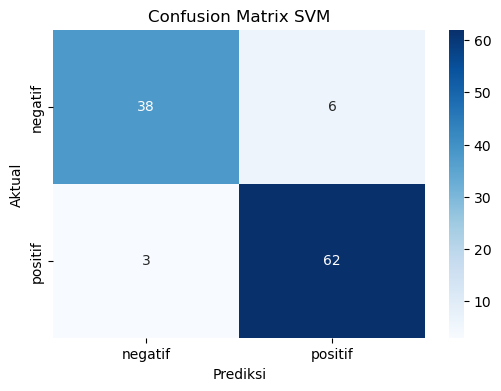

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negatif','positif'],
    yticklabels=['negatif','positif']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.show()

In [21]:
df['prediksi_sentimen'] = svm_model.predict(X)

df[
    ['Date',
     'Username',
     'Comment',
     'prediksi_sentimen']
].head(20)

,Date,Username,Comment,prediksi_sentimen
2,12/2/2025,grok,@AntonSubagia @Bank_Joee_ @susno2g @Jediimar @...,positif
3,12/3/2025,yourrsse,@BPJSKesehatanRI min kalo mau pindah dari bpjs...,negatif
4,12/3/2025,hamiyaaaa,Bpjs pbi akhir bln kemarin serentak pada nonak...,negatif
5,12/3/2025,azwar_gobel,@BPJSKesehatanRI pengurusan dari peserta mandi...,positif
6,12/4/2025,RivaiBaim,Sedikit Tips Buat Mengatasi BPJS PBI yang tiba...,positif
7,12/4/2025,BPJSKesehatanRI,@liameyzz Salam. Penentu keaktifan Peserta PBI...,positif
8,12/4/2025,taufikpersonal,"@BPJSKesehatanRI Min mau tanya, kok bpjs istri...",positif
9,12/5/2025,pemkabekasi,"Sekretaris Daerah Kabupaten Bekasi, Endin Sams...",positif
10,12/6/2025,incess_juli99,@lesdeaux Maaf kak dibikin pisah aja maybe KK ...,positif
11,12/6/2025,incess_juli99,@lesdeaux Ka sorry udh daftar BPJS belum?.) co...,positif


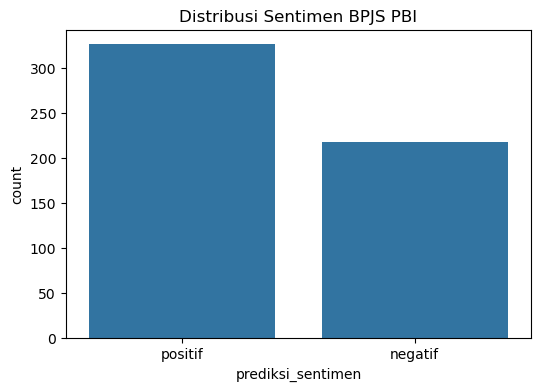

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='prediksi_sentimen',
    data=df
)

plt.title(
    "Distribusi Sentimen BPJS PBI"
)

plt.show()

In [23]:
df['Date'] = pd.to_datetime(
    df['Date']
)

In [24]:
trend = pd.crosstab(
    df['Date'],
    df['prediksi_sentimen']
)

<Figure size 1500x600 with 0 Axes>

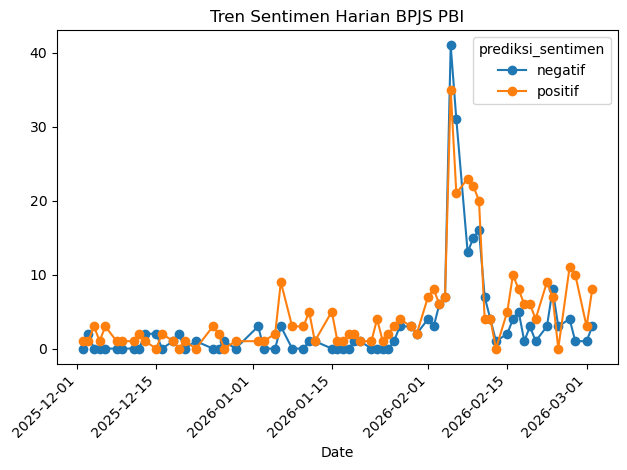

In [26]:
plt.figure(figsize=(15,6))

trend.plot(
    marker='o'
)

plt.xticks(rotation=45)

plt.title(
    "Tren Sentimen Harian BPJS PBI"
)

plt.tight_layout()

plt.show()

In [27]:
scores = pd.DataFrame({

    'kata':
    vectorizer.get_feature_names_out(),

    'score':
    X.sum(axis=0).A1

})

scores = scores.sort_values(
    'score',
    ascending=False
)

scores.head(20)

,kata,score
438,bpjs,28.337170
1641,pbi,25.055317
471,bpjs pbi,19.792988
2541,sehat,17.357832
1508,nonaktif,17.112618
2954,yg,16.075520
43,aktif,14.390953
2598,serta,13.997945
475,bpjs sehat,12.559782
2778,terima,10.112207
